***URL of problem : https://www.kaggle.com/competitions/news-classification-challenge/overview***

In [66]:
import os
import numpy as np
import pandas as pd
import re
import unicodedata
from collections import Counter
import warnings

import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords

import sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder

import torch
from torch import nn
from torch import optim
from torch.utils.data import TensorDataset,DataLoader
import matplotlib.pyplot as plt


nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

warnings.simplefilter(action = 'ignore')

device = torch.device('cuda')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [88]:
VOCAB_SIZE = 5000
MAX_TOKEN_LEN = 15
BATCH_SIZE = 32
EPOCH = 100

In [68]:
Sample_input = {
    'Headline' : [
        'Digital India initiative boosts health sector',
        'Citizens protest against women issue in Mumbai',
        'Indian womenÃ¢â‚¬â„¢s team secures victory in women final',
        'WHO praises IndiaÃ¢â‚¬â„¢s efforts in combating space',
    ],
    'Category' : ['Technology','Society','Sports','Health']
}
#X_train = pd.DataFrame(Sample_input)
X_train = pd.read_csv('https://huggingface.co/datasets/NHANGIOI/Learning-Training/resolve/main/news-classification-challenge/Train.csv',index_col = 'Id')
y_train = X_train['Category']
X_train.drop(columns = 'Category',inplace = True)

In [69]:
Label_encode = LabelEncoder()
y_train = Label_encode.fit_transform(y_train)

In [70]:
label_type = pd.unique(y_train)
for cat in label_type:
    res = (y_train == cat).sum()
    print(f"{cat} : {res / y_train.shape[0]}")

6 : 0.1002
7 : 0.0998
5 : 0.0946
0 : 0.0982
2 : 0.1028
8 : 0.0972
4 : 0.1014
9 : 0.0922
1 : 0.1094
3 : 0.1042


In [71]:
def normalize_text(text,replace_num = True,is_lower = True,remove_punctuation = True):
    text = unicodedata.normalize('NFKC',text)
    text = ' '.join(text.split())
    if replace_num:
        text = re.sub(r"\d+",'<NUM>',text)
    if remove_punctuation:
        text = re.sub(r"[^\w\s.,;]",'',text)
    if is_lower:
        text = text.lower()
    return text

def tokenize_text(text,window_size = 3):
    text = normalize_text(text,replace_num = False)
    tokens = word_tokenize(text)

    stopwords_lists = set(stopwords.words("english"))
    tokens = [token for token in tokens if token not in stopwords_lists]
    
    negative_words = ['not','no',"n't",'never','neither','nobody','nothing',
                      "isn't","haven't","wasn't","weren't","aren't"]
    punctuation_words = ['.',';',',']
    conjuntion_words = ['and','or','though','although','so','because',
                        'moreover','since','but','while','before','unless','if','before','after']
    
    res = []
    counts = 0
    for token in tokens:
        if token in negative_words:
            counts = window_size
            res.append(token)
        elif token in punctuation_words or token in conjuntion_words:
            counts = 0
            res.append(token)
        elif counts > 0:
            counts -= 1
            res.append(f"NOT_{token}")
        else:
            res.append(token)
    return res

def build_vocab(token_list,min_freq = 1):
    cnt = Counter()
    vocab = {
        '<UNK>' : 0,
        '<PAD>' : 1,
    }
    for tokens in token_list:
        cnt.update(tokens)
    
    words_list = [(token,freq) for token,freq in cnt.items() if freq >= min_freq]
    words_list.sort(key = lambda X: (-X[1],X[0]))
    words_list[:len(words_list) - 2]
    
    idx = 2
    for word,freq in words_list:
        vocab[word] = idx
        idx += 1
    return vocab

def vectorize_padding(tokens,vocab):
    tokens =  [vocab.get(token,0) for token in tokens]
    
    while(len(tokens) > MAX_TOKEN_LEN):
        del tokens[len(tokens) - 1]
    while(len(tokens) < MAX_TOKEN_LEN):
        tokens.append(1)
    return tokens

In [72]:
def preprocess(df):
    df = [tokenize_text(df.iloc[row]) for row in range(df.shape[0])]
    vocab = build_vocab(df)
    df = [vectorize_padding(df[row],vocab) for row in range(len(df))]
    return torch.tensor(df)
def build_train_batch(X_train,y_train):
    X_train = preprocess(X_train)
    
    y_train = torch.tensor(y_train)
    
    return DataLoader(
        TensorDataset(X_train,y_train),
        batch_size = BATCH_SIZE,
        shuffle = True,
        pin_memory = True,
    )
def build_test_batch(X_test):
    X_test = preprocess(X_test)
    return DataLoader(
        X_test,
        batch_size = BATCH_SIZE,
        pin_memory = True,
    )

In [73]:
X_train = pd.Series(X_train.squeeze())
y_train = pd.Series(y_train.squeeze())
dataset = build_train_batch(X_train,y_train)

In [94]:
class model_classification(nn.Module):
    def __init__(self,embedding_dim,hidden_dim,output_size):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings = VOCAB_SIZE,
            embedding_dim = embedding_dim,
            padding_idx = 1,
        )
        self.rnn = nn.GRU(
            input_size = embedding_dim,
            hidden_size = hidden_dim,
            batch_first = True,
            dropout = 0.2,
        )
        self.MLP = nn.Sequential(
            nn.Linear(hidden_dim,1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(p = 0.2),
            
            nn.Linear(1024,512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p = 0.2),
            
            nn.Linear(512,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p = 0.2),
            
            nn.Linear(256,output_size)
        )
    def forward(self,X):
        X = self.embedding(X)
        X,h_n = self.rnn(X)
        last_hidden = h_n[-1]
        X = self.MLP(last_hidden)
        return X

In [95]:
model = model_classification(128,128,output_size = 10).to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr = 0.001)

In [96]:
total_loss = []
for epoch in range(EPOCH):
    model.train()
    sum_loss = 0.0
    for X_batch,y_batch in dataset:
        X_batch = X_batch.to(device)
        y_batch = y_batch.long().to(device)
        
        optimizer.zero_grad()
        
        preds = model(X_batch)
        loss = loss_func(preds,y_batch)
        
        loss.backward()
        optimizer.step()
        
        sum_loss += loss.item()
    res = sum_loss / len(dataset)
    total_loss.append(res)
    print(f"loss of epoch {epoch} : {res}")

loss of epoch 0 : 0.1891855997223241
loss of epoch 1 : 0.025493290901160353
loss of epoch 2 : 0.02918201711349142
loss of epoch 3 : 0.04834523195494263
loss of epoch 4 : 0.001981066341718042
loss of epoch 5 : 0.0022932061333999715
loss of epoch 6 : 0.0008740811223615773
loss of epoch 7 : 0.0007786100183351849
loss of epoch 8 : 0.0003778071072383392
loss of epoch 9 : 0.00027534151356185306
loss of epoch 10 : 0.00024050839656295113
loss of epoch 11 : 0.004287762652429998
loss of epoch 12 : 0.05025486255403472
loss of epoch 13 : 0.007123980550928699
loss of epoch 14 : 0.005496828418090097
loss of epoch 15 : 0.00789133917830794
loss of epoch 16 : 0.0027262813581131876
loss of epoch 17 : 0.0004586542395401782
loss of epoch 18 : 0.0003708217945404033
loss of epoch 19 : 0.0010883775486516844
loss of epoch 20 : 0.013577375794246654
loss of epoch 21 : 0.027630474712127956
loss of epoch 22 : 0.012252024739256254
loss of epoch 23 : 0.01597742927701889
loss of epoch 24 : 0.0005405259849145863
loss

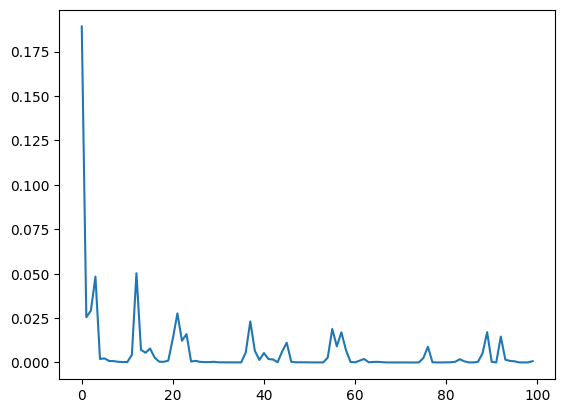

In [97]:
plt.plot(np.arange(len(total_loss)),total_loss)
plt.show()

In [ ]:
X_test = pd.read_csv('https://huggingface.co/datasets/NHANGIOI/Learning-Training/resolve/main/news-classification-challenge/Test.csv',index_col = 'Id')
test_index = X_test.index
X_test = pd.Series(X_test.squeeze())
X_test = build_test_batch(X_test)
preds = []
model.eval()
with torch.no_grad():
    for X_batch in X_test:
        X_batch = X_batch.to(device)

        pred_batch = model(X_batch)
        pred_batch = torch.argmax(pred_batch,dim = 1)
        preds.extend(pred_batch.cpu().numpy())
preds = Label_encode.inverse_transform(preds)
submission = pd.DataFrame({
    'id' : test_index,
    'category' : preds
})
submission.to_csv('submission.csv',index = False)